In [1]:
import pandas as pd

df = pd.read_csv("sales.csv")
df.columns.tolist()

['sale_id',
 'branch',
 'city',
 'customer_type',
 'gender',
 'product_name',
 'product_category',
 'unit_price',
 'quantity',
 'tax',
 'total_price',
 'reward_points']

In [2]:
df.head()

,sale_id,branch,city,customer_type,gender,product_name,product_category,unit_price,quantity,tax,total_price,reward_points
0,1,A,New York,Member,Male,Shampoo,Personal Care,5.50,3,1.16,17.66,1
1,2,B,Los Angeles,Normal,Female,Notebook,Stationery,2.75,10,1.93,29.43,0
2,3,A,New York,Member,Female,Apple,Fruits,1.20,15,1.26,19.26,1
3,4,A,Chicago,Normal,Male,Detergent,Household,7.80,5,2.73,41.73,0
4,5,B,Los Angeles,Member,Female,Orange Juice,Beverages,3.50,7,1.72,26.22,2


In [2]:
import pandas as pd

df = pd.read_csv("sales.csv")
df.head()

,sale_id,branch,city,customer_type,gender,product_name,product_category,unit_price,quantity,tax,total_price,reward_points
0,1,A,New York,Member,Male,Shampoo,Personal Care,5.50,3,1.16,17.66,1
1,2,B,Los Angeles,Normal,Female,Notebook,Stationery,2.75,10,1.93,29.43,0
2,3,A,New York,Member,Female,Apple,Fruits,1.20,15,1.26,19.26,1
3,4,A,Chicago,Normal,Male,Detergent,Household,7.80,5,2.73,41.73,0
4,5,B,Los Angeles,Member,Female,Orange Juice,Beverages,3.50,7,1.72,26.22,2


In [3]:
df.isnull().sum()

sale_id             0
branch              0
city                0
customer_type       0
gender              0
product_name        0
product_category    0
unit_price          0
quantity            0
tax                 0
total_price         0
reward_points       0
dtype: int64

In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df.dtypes

sale_id               int64
branch                  str
city                    str
customer_type           str
gender                  str
product_name            str
product_category        str
unit_price          float64
quantity              int64
tax                 float64
total_price         float64
reward_points         int64
dtype: object

In [6]:
# 1. (Chiffre d'affaires total)
ca_total = df['total_price'].sum()
print(f"CA Total: {ca_total:.2f} $")

# 2. عدد الطلبات
nb_commandes = df.shape[0]
print(f"Nombre de commandes: {nb_commandes}")

# 3. المنتوج الأكثر مبيعا (بالكمية)
produit_top = df.groupby('product_name')['quantity'].sum().idxmax()
print(f"Produit le plus vendu: {produit_top}")

# 4. أحسن مدينة (بحسب الإيرادات)
ville_top = df.groupby('city')['total_price'].sum().idxmax()
print(f"Meilleure ville: {ville_top}")

# 5. أحسن فئة منتوجات
categorie_top = df.groupby('product_category')['total_price'].sum().idxmax()
print(f"Meilleure catégorie: {categorie_top}")

# 6. مقارنة Member vs Normal
comparaison = df.groupby('customer_type')['total_price'].sum()
print(comparaison)

CA Total: 118583.90 $
Nombre de commandes: 1000
Produit le plus vendu: Shampoo
Meilleure ville: Chicago
Meilleure catégorie: Personal Care
customer_type
Member    63213.63
Normal    55370.27
Name: total_price, dtype: float64


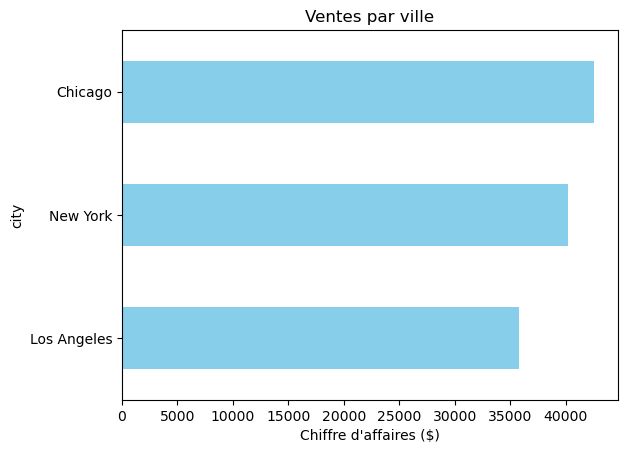

In [7]:
import matplotlib.pyplot as plt

# المبيعات حسب المدينة
df.groupby('city')['total_price'].sum().sort_values().plot(kind='barh', color='skyblue')
plt.title('Ventes par ville')
plt.xlabel('Chiffre d\'affaires ($)')
plt.show()

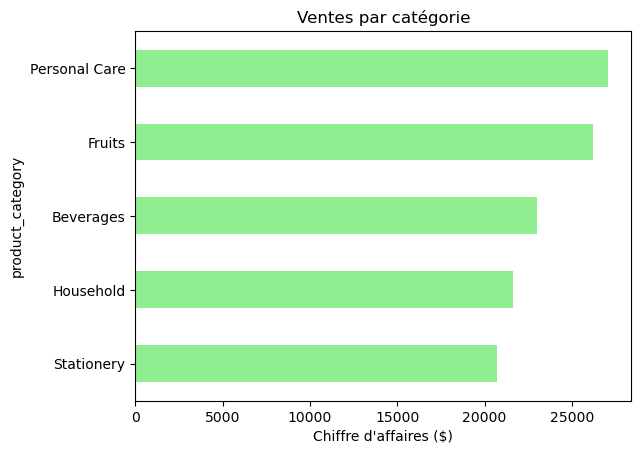

In [8]:
# المبيعات حسب الفئة
df.groupby('product_category')['total_price'].sum().sort_values().plot(kind='barh', color='lightgreen')
plt.title('Ventes par catégorie')
plt.xlabel('Chiffre d\'affaires ($)')
plt.show()

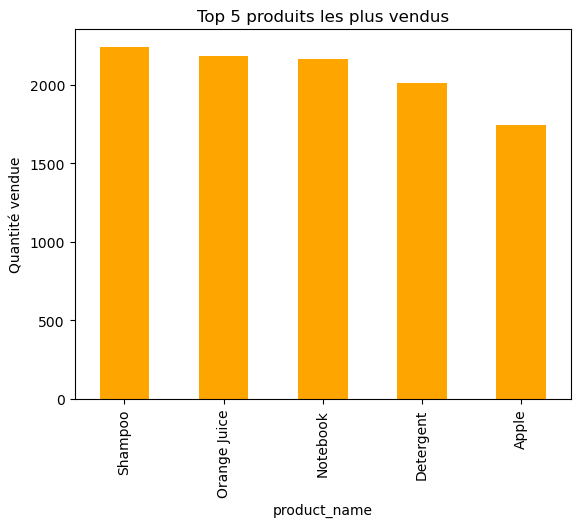

In [9]:
# Top 5 منتوجات
df.groupby('product_name')['quantity'].sum().sort_values(ascending=False).head(5).plot(kind='bar', color='orange')
plt.title('Top 5 produits les plus vendus')
plt.ylabel('Quantité vendue')
plt.show()

In [10]:
df.to_csv("sales_clean.csv", index=False)
print("Fichier exporté avec succès!")

Fichier exporté avec succès!
